In [1]:
# Core Python
import os
import yaml

# CREDIT framework
import torch
from credit.datasets.era5_multistep_batcher import Predict_Dataset_Batcher
from credit.datasets.load_dataset_and_dataloader import BatchForecastLenDataLoader
from credit.parser import credit_main_parser
from credit.datasets import setup_data_loading
from credit.models import load_model
from credit.transforms import load_transforms, Normalize_ERA5_and_Forcing
from credit.datasets.era5 import ERA5Dataset
from credit.samplers import DistributedMultiStepBatchSampler
from credit.datasets.era5_multistep_batcher import Predict_Dataset_Batcher
from credit.datasets.load_dataset_and_dataloader import BatchForecastLenDataLoader
from credit.transforms import Normalize_ERA5_and_Forcing
# from tails.hurricane_genesis_ffs import HurricaneGenesisFFS, HurricaneGenesisFFS_CPS
from tails.hurricane_genesis_ffs import HurricaneGenesisFFS
from torch.utils.data import DataLoader

import warnings
warnings.filterwarnings('ignore')

In [2]:
import torch
import numpy as np
import xarray as xr
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass
from datetime import datetime, timedelta
import copy
import random
import string
from pathlib import Path
import pickle
import pandas as pd

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.ndimage import gaussian_filter

from credit.output import make_xarray
from credit.datasets.era5_multistep_batcher import Predict_Dataset_Batcher
from credit.datasets.load_dataset_and_dataloader import BatchForecastLenDataLoader
from credit.data import concat_and_reshape, reshape_only
from credit.interp import full_state_pressure_interpolation, mean_sea_level_pressure_simple as mslp_simple
from tails.ffs_logger import FFSLogger
from tails.cyclone_phase_tracker import CyclonePhaseTracker

import warnings
warnings.filterwarnings('ignore')


class IFSEnsembleTracker(HurricaneGenesisFFS):
    """
    Track storms in IFS ensemble using FFS tracking logic.
    Inherits all tracking methods from HurricaneGenesisFFS.
    """
    
    def __init__(self, 
                 model, 
                 state_transformer, 
                 config, 
                 initial_dataset,
                 dataset_params,
                 output_dir='./ffs_output',
                 state_A=1008, 
                 state_B=982, 
                 interfaces=[1000, 988, 980, 975, 970],
                 decorrelation_interface=None,
                 max_attempts_without_success=1000,
                 worker_id=0,
                 rank=0,
                 world_size=1,
                 ic_dirname=None,
                 use_cps=True,
                 ifs_path=None):
        
        # Initialize parent
        super().__init__(
            model=model,
            state_transformer=state_transformer,
            config=config,
            initial_dataset=initial_dataset,
            dataset_params=dataset_params,
            output_dir=output_dir,
            state_A=state_A,
            state_B=state_B,
            interfaces=interfaces,
            decorrelation_interface=decorrelation_interface,
            max_attempts_without_success=max_attempts_without_success,
            worker_id=worker_id,
            rank=rank,
            world_size=world_size,
            ic_dirname=ic_dirname,
            use_cps=use_cps
        )
        
        self.ifs_path = Path(ifs_path) if ifs_path else None
        self.ds = None
        self.ds_filtered = None

    def _plot_mslp(self, mslp_hpa, basin_mask, datetime_str, center_lat, center_lon, 
                   center_val, show_marker=False, marker_label=None):
        """Plot MSLP field with optional crossing marker - IFS version."""
        from IPython.display import display, clear_output
        
        if self.fig is None:
            plt.ion()
            self.fig = plt.figure(figsize=(16, 10))
            self.ax = self.fig.add_subplot(1, 1, 1, 
                projection=ccrs.LambertConformal(
                    central_longitude=-60.0,
                    central_latitude=35.0,
                    standard_parallels=(30, 50)
                ))
        
        self.ax.clear()
        
        # Use IFS grid from loaded data
        lats = self.ds_filtered.latitude.values
        lons = self.ds_filtered.longitude.values
        
        # Transpose mslp_hpa from (lon, lat) to (lat, lon)
        mslp_smooth = gaussian_filter(mslp_hpa, sigma=1.0)
        
        self.ax.set_extent([-100, -10, 0, 85], crs=ccrs.PlateCarree())
        
        from matplotlib.colors import BoundaryNorm
        levels = np.arange(960, 1032, 2)
        norm = BoundaryNorm(levels, ncolors=plt.cm.RdBu.N, clip=True)
        
        LON, LAT = np.meshgrid(lons, lats, indexing='xy')
        
        pcm = self.ax.pcolormesh(LON, LAT, mslp_smooth, 
                        norm=norm,
                        cmap='RdBu_r',
                        transform=ccrs.PlateCarree(), 
                        shading='nearest', zorder=1)
        
        self.ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=1.0)
        self.ax.add_feature(cfeature.STATES.with_scale("50m"), linewidth=0.5, alpha=0.6)
        
        if show_marker and center_lat is not None and center_lon is not None:
            self.ax.plot(center_lon, center_lat, marker='*', markersize=24,
                    markeredgecolor='yellow', markeredgewidth=2.5, color='red',
                    transform=ccrs.PlateCarree(), zorder=10,
                    label=marker_label or 'Crossing')
        
        gl = self.ax.gridlines(draw_labels=True, linewidth=0.6, alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        
        title_parts = []
        if datetime_str:
            title_parts.append(datetime_str)
    
        if center_lat is not None and center_lon is not None:
            lat_dir = 'N' if center_lat >= 0 else 'S'
            lon_dir = 'W' if center_lon < 0 else 'E'
            title_parts.append(f"MSLP: {center_val:.1f} hPa @ ({abs(center_lat):.1f}°{lat_dir}, {abs(center_lon):.1f}°{lon_dir})")
        else:
            title_parts.append(f"MSLP: {center_val:.1f} hPa")
        
        self.ax.set_title('\n'.join(title_parts), fontsize=14, fontweight="bold")
        
        if show_marker:
            self.ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
        
        if not self._colorbar_added:
            cbar = plt.colorbar(pcm, ax=self.ax, label="MSLP (hPa)", shrink=0.8)
            cbar.set_ticks(np.arange(960, 1032, 4))
            self._colorbar_added = True
        
        clear_output(wait=True)
        display(self.fig)
        plt.pause(0.01)

    def visualize_member(self, init_time, member_idx):
        """
        Run process_member with visualization enabled.
        Uses FFS base class plotting functions.
        """
        # Enable visualization
        self.enable_visualization()
        
        try:
            result = self.process_member(init_time, member_idx)
            return result
        finally:
            # Disable when done
            self.disable_visualization()
    
    def load_ifs_data(self, init_times: list = None):
        """
        Load IFS ensemble data.
        
        Args:
            init_times: List of initialization times (e.g., ['2022-09-21', '2022-09-28'])
                       If None, loads all 2022 initializations at 00:00 UTC
        """
        if self.ifs_path is None:
            raise ValueError("ifs_path not set")
        
        print(f"Loading IFS data from {self.ifs_path}...")
        self.ds = xr.open_zarr(self.ifs_path, consolidated=True)
        
        if init_times is not None:
            init_times = [pd.to_datetime(t) for t in init_times]
            self.ds_filtered = self.ds.sel(time=init_times)
        else:
            ds_year = self.ds.sel(time=self.ds.time.dt.year == 2022)
            self.ds_filtered = ds_year.sel(time=ds_year.time.dt.hour == 0)
        
        # Always take full 15 days of forecast
        max_lead = pd.Timedelta(days=15)
        print(f"Max lead: {max_lead}")
        print(f"prediction_timedelta dtype: {self.ds_filtered.prediction_timedelta.dtype}")
        print(f"First few values: {self.ds_filtered.prediction_timedelta.values[:5]}")

        valid_leads = self.ds_filtered.prediction_timedelta <= max_lead
        print(f"Valid leads count: {valid_leads.sum()}")

        self.ds_filtered = self.ds_filtered.isel(prediction_timedelta=valid_leads)
        
        print(f"Loaded {len(self.ds_filtered.time)} initializations")
        print(f"Ensemble size: {len(self.ds_filtered.number)}")

    def get_basin_mask(self) -> np.ndarray:
        """Create basin mask for IFS grid."""
        if self.ds_filtered is None:
            raise ValueError("Must call load_ifs_data first")
        
        lats = self.ds_filtered.latitude.values
        lons = self.ds_filtered.longitude.values
        lons_180 = np.where(lons > 180, lons - 360, lons)
        
        lat_mask = (lats >= self.basin['lat_min']) & (lats <= self.basin['lat_max'])
        lon_mask = (lons_180 >= self.basin['lon_min']) & (lons_180 <= self.basin['lon_max'])
        
        return lat_mask[:, None] & lon_mask[None, :]
    
    def process_member(self, init_time, member_idx):
        """
        Track storms in one IFS member using FFS tracking logic.
        Tracks ALL storms but only counts genesis events (not pre-existing).
        
        Returns:
            dict with A→B transitions, λ₀ crossings, etc.
        """
        # Use isel for integer indexing, not sel
        traj = self.ds_filtered.sel(time=init_time).isel(number=member_idx)
        
        lats = traj.latitude.values
        lons = traj.longitude.values
        lons_180 = np.where(lons > 180, lons - 360, lons)
        
        basin_mask = self.get_basin_mask()
        
        # Initialize tracking (matching FFS flux mode)
        self.tracked_storms = {}
        self.next_storm_id = 0
        if self.use_cps:
            self.storm_track_history = {}
        
        initial_storm_ids = set()  # Track which storms exist at t=0 (pre-existing)
        lambda0_crossings = []
        b_state_events = []
        self.interface_crossings = {i: [] for i in range(len(self.interfaces))}
        
        n_steps = len(traj.prediction_timedelta)
        
        for lead_idx in range(n_steps):
            # Get MSLP field
            mslp_pa = traj.mean_sea_level_pressure.isel(prediction_timedelta=lead_idx).values
            # Remove any extra dimensions
            while mslp_pa.ndim > 2:
                mslp_pa = mslp_pa[0]
            mslp_hpa_raw = mslp_pa / 100.0
            
            if mslp_hpa_raw.shape == (len(lons), len(lats)):
                mslp_hpa = mslp_hpa_raw.T
            else:
                mslp_hpa = mslp_hpa_raw
            
            stop_tracking_new = (lead_idx > 60)
            
            # TRACKED STORMS (no basin constraint)
            tracked_minima = []
            if len(self.tracked_storms) > 0:
                for storm_id, storm_info in self.tracked_storms.items():
                    storm_lat, storm_lon = storm_info['location']
                    
                    lat_grid, lon_grid = np.meshgrid(lats, lons_180, indexing="ij")
                    dist = np.sqrt((lat_grid - storm_lat)**2 + (lon_grid - storm_lon)**2)
                    
                    mslp_smooth = gaussian_filter(mslp_hpa, sigma=1.5)
                    local = np.where(dist < 12.0, mslp_smooth, np.nan)
                    
                    if np.all(np.isnan(local)):
                        continue
                    
                    idx = np.nanargmin(local)
                    i, j = np.unravel_index(idx, local.shape)
                    
                    min_lat = float(lats[i])
                    min_lon = float(lons_180[j])
                    min_mslp = float(mslp_hpa[i, j])
                    
                    # LSM check for low latitudes (matching FFS)
                    if min_lat < 20.0:
                        lsm_value = self.land_sea_mask[i, j]
                        if lsm_value > 0.5:
                            continue
                    
                    tracked_minima.append((min_mslp, min_lat, min_lon))
            
            # NEW STORMS (with basin constraint) - use FFS method
            new_minima = []
            if not stop_tracking_new:
                exclude_centers = [s['location'] for s in self.tracked_storms.values()]
                new_minima = self._find_local_mslp_minima(
                    mslp_hpa, lats, lons_180, basin_mask,
                    exclude_centers=exclude_centers,
                    exclude_radius_deg=12.0
                )
            
            # Combine and merge
            minima = tracked_minima + new_minima
            
            merged_minima = []
            for min_mslp, min_lat, min_lon in minima:
                merged = False
                for idx, (m_mslp, m_lat, m_lon) in enumerate(merged_minima):
                    dist = np.sqrt((min_lat - m_lat)**2 + (min_lon - m_lon)**2)
                    if dist < 12.0:
                        if min_mslp < m_mslp:
                            merged_minima[idx] = (min_mslp, min_lat, min_lon)
                        merged = True
                        break
                if not merged:
                    merged_minima.append((min_mslp, min_lat, min_lon))
            
            minima = merged_minima
            
            # Match to tracked storms (matching FFS)
            matched_minima = set()
            for storm_id, storm_info in list(self.tracked_storms.items()):
                storm_lat, storm_lon = storm_info['location']
                best_match = None
                best_dist = float('inf')
                
                for min_idx, (min_mslp, min_lat, min_lon) in enumerate(minima):
                    if min_idx in matched_minima:
                        continue
                    dist = np.sqrt((min_lat - storm_lat)**2 + (min_lon - storm_lon)**2)
                    if dist < 12.0 and dist < best_dist:
                        best_match = min_idx
                        best_dist = dist
                
                if best_match is not None:
                    min_mslp, min_lat, min_lon = minima[best_match]
                    self.tracked_storms[storm_id]['location'] = (min_lat, min_lon)
                    self.tracked_storms[storm_id]['mslp'] = min_mslp
                    self.tracked_storms[storm_id]['lost_count'] = 0
                    matched_minima.add(best_match)
                else:
                    self.tracked_storms[storm_id]['lost_count'] += 1
            
            # Add new storms
            for min_idx, (min_mslp, min_lat, min_lon) in enumerate(minima):
                if min_idx not in matched_minima and not stop_tracking_new:
                    storm_id = self.next_storm_id
                    self.next_storm_id += 1
                    self.tracked_storms[storm_id] = {
                        'location': (min_lat, min_lon),
                        'mslp': min_mslp,
                        'saved': False,
                        'lost_count': 0
                    }
                    if lead_idx == 0:
                        initial_storm_ids.add(storm_id)  # Mark as pre-existing
            
            # Remove lost storms
            for storm_id in list(self.tracked_storms.keys()):
                if self.tracked_storms[storm_id]['lost_count'] >= 2:
                    del self.tracked_storms[storm_id]
                    if self.use_cps and storm_id in self.storm_track_history:
                        del self.storm_track_history[storm_id]
            
            # ET removal check (matching FFS flux mode lines 486-506)
            if self.use_cps and len(self.tracked_storms) > 0:
                for storm_id in list(self.tracked_storms.keys()):
                    storm = self.tracked_storms[storm_id]
                    storm_lat, storm_lon = storm['location']
                    
                    if storm_lat > 50.0 or storm_lon > -10.0:
                        # TODO: Add CPS check here using IFS data
                        # For now, just note that storm is at high latitude
                        pass
            
            # Check each storm for λ₀ crossing and B-state
            for storm_id in list(self.tracked_storms.keys()):
                storm = self.tracked_storms[storm_id]
                
                # B-state check (only count if NOT pre-existing)
                if storm['mslp'] < self.state_B_threshold:
                    if storm_id not in initial_storm_ids:  # Only count genesis→B
                        b_state_events.append({
                            'storm_id': storm_id,
                            'lead_idx': lead_idx,
                            'mslp': storm['mslp'],
                            'lat': storm['location'][0],
                            'lon': storm['location'][1]
                        })
                    del self.tracked_storms[storm_id]
                    if self.use_cps and storm_id in self.storm_track_history:
                        del self.storm_track_history[storm_id]
                    continue
                
                # Dissipation
                if storm['mslp'] > self.state_A_threshold:
                    del self.tracked_storms[storm_id]
                    if self.use_cps and storm_id in self.storm_track_history:
                        del self.storm_track_history[storm_id]
                    continue
                
                # Check ALL interface crossings (for non-pre-existing storms only)
                if storm_id not in initial_storm_ids:
                    # Check ALL interfaces, not just [1:]
                    for interface_idx, interface_val in enumerate(self.interfaces):
                        # Check if storm crossed this interface and hasn't been recorded yet
                        if not storm.get(f'crossed_interface_{interface_idx}', False):
                            if storm['mslp'] < interface_val:
                                # Verify local minimum
                                storm_lat, storm_lon = storm['location']
                                lat_idx = np.argmin(np.abs(lats - storm_lat))
                                lon_idx = np.argmin(np.abs(lons_180 - storm_lon))
                                
                                i_min = max(0, lat_idx - 1)
                                i_max = min(mslp_hpa.shape[0], lat_idx + 2)
                                j_min = max(0, lon_idx - 1)
                                j_max = min(mslp_hpa.shape[1], lon_idx + 2)
                                
                                nbhd = mslp_hpa[i_min:i_max, j_min:j_max]
                                center_val = mslp_hpa[lat_idx, lon_idx]
                                
                                if np.all(center_val <= nbhd):
                                    # Record interface crossing
                                    self.interface_crossings[interface_idx].append({
                                        'storm_id': storm_id,
                                        'lead_idx': lead_idx,
                                        'mslp': storm['mslp'],
                                        'lat': storm_lat,
                                        'lon': storm_lon
                                    })
                                    storm[f'crossed_interface_{interface_idx}'] = True
                                    
                                    # Special handling for λ₀
                                    if interface_idx == 0:
                                        lambda0_crossings.append({
                                            'storm_id': storm_id,
                                            'lead_idx': lead_idx,
                                            'mslp': storm['mslp'],
                                            'lat': storm_lat,
                                            'lon': storm_lon
                                        })
                                        storm['saved'] = True

            # ← VISUALIZATION (after minima is computed)
            if self.visualize_mslp:
                # Get actual datetime
                lead_hours = float(traj.prediction_timedelta.values[lead_idx] / np.timedelta64(1, 'h'))
                actual_datetime = pd.Timestamp(init_time) + pd.Timedelta(hours=lead_hours)
                datetime_str = actual_datetime.strftime('%Y-%m-%d %H:%M UTC')    
                actual_datetime = pd.Timestamp(init_time) + pd.Timedelta(hours=float(traj.prediction_timedelta.values[lead_idx] / np.timedelta64(1, 'h')))
                datetime_str = actual_datetime.strftime('%Y-%m-%d %H:%M UTC')
                
                # Always show strongest storm
                if len(minima) > 0:
                    marker_mslp, marker_lat, marker_lon = min(minima, key=lambda x: x[0])
                else:
                    basin_mslp = np.where(basin_mask, mslp_hpa, np.nan)
                    min_idx = np.nanargmin(basin_mslp)
                    i, j = np.unravel_index(min_idx, basin_mslp.shape)
                    marker_mslp = float(mslp_hpa[i, j])
                    marker_lat = float(lats[i])
                    marker_lon = float(lons_180[j])
                
                # Check if λ₀ crossing happened this timestep
                show_marker = False
                marker_label = None
                for crossing in lambda0_crossings:
                    if crossing['lead_idx'] == lead_idx:
                        show_marker = True
                        marker_label = f"λ₀ CROSSING (Storm {crossing['storm_id']})"
                        break
                
                self._plot_mslp(mslp_hpa, basin_mask, datetime_str, 
                                marker_lat, marker_lon, marker_mslp,
                                show_marker=show_marker, marker_label=marker_label)
                
        
        lead_hours = float(traj.prediction_timedelta.values[-1] / np.timedelta64(1, 'h'))
        total_days = lead_hours / 24.0
        
        return {
            'member_idx': member_idx,
            'init_time': init_time,
            'n_initial_storms': len(initial_storm_ids),
            'crossings': lambda0_crossings,
            'b_state_events': b_state_events,
            'interface_crossings': self.interface_crossings,  # ← ADD THIS
            'total_days': total_days,
            'lambda0_rate': len(lambda0_crossings) / total_days if total_days > 0 else 0,
            'b_state_rate': len(b_state_events) / total_days if total_days > 0 else 0
        }

In [3]:
filepath = "/glade/derecho/scratch/schreck/CREDIT_runs/ensemble/scheduler/" # "/glade/campaign/cisl/aiml/credit/models/one_degree_wxformer_6hr_ensemble/"
device = "cuda"

with open(os.path.join(filepath, "model.yml"), "r") as f:
    conf = yaml.safe_load(f)

conf['predict']['interp_pressure']['pressure_levels'] = [300., 600., 900.]
conf = credit_main_parser(conf, parse_training=False, parse_predict=True, print_summary=False)
data_config = setup_data_loading(conf)

ensemble_size = 1
conf["trainer"]["ensemble_size"] = ensemble_size
conf["predict"]["ensemble_size"] = ensemble_size

In [4]:
model = load_model(conf, load_weights=True).to(device)
model = model.eval()

In [12]:
# start = "2022-09-17 00:00:00"
# end   = "2022-09-27 00:00:00"

start = "2022-09-27 00:00:00"
end   = "2022-10-12 00:00:00"

forecast_times = [[start, end]]

dataset_params = dict(
    varname_upper_air=data_config["varname_upper_air"],
    varname_surface=data_config["varname_surface"],
    varname_dyn_forcing=data_config["varname_dyn_forcing"],
    varname_forcing=data_config["varname_forcing"],
    varname_static=data_config["varname_static"],
    varname_diagnostic=data_config["varname_diagnostic"],
    filenames=data_config["all_ERA_files"],
    filename_surface=data_config["surface_files"],
    filename_dyn_forcing=data_config["dyn_forcing_files"],
    filename_forcing=data_config["forcing_files"],
    filename_static=data_config["static_files"],
    filename_diagnostic=data_config["diagnostic_files"],
    lead_time_periods=6,
    history_len=data_config["history_len"],
    skip_periods=data_config["skip_periods"],
    transform=load_transforms(conf),
    sst_forcing=data_config["sst_forcing"],
    batch_size=1,
    rank=0,
    world_size=1,
)

In [13]:
initial_dataset = Predict_Dataset_Batcher(
    **dataset_params,
    fcst_datetime=forecast_times,
)

initial_loader = BatchForecastLenDataLoader(initial_dataset)

# Initialize FFS with tracking
ffs = HurricaneGenesisFFS(
    model=model,
    state_transformer=Normalize_ERA5_and_Forcing(conf),
    config=conf,
    initial_dataset=initial_dataset,
    dataset_params=dataset_params,
    interfaces=[1000, 988, 980, 975, 970],
    state_A=1008,
    state_B=965,
    max_attempts_without_success=200,
    output_dir="./notebook",
    rank=0,
    world_size=1,
    worker_id=0,
)


✓ CPS tracker initialized (Hart 2003 formulation)


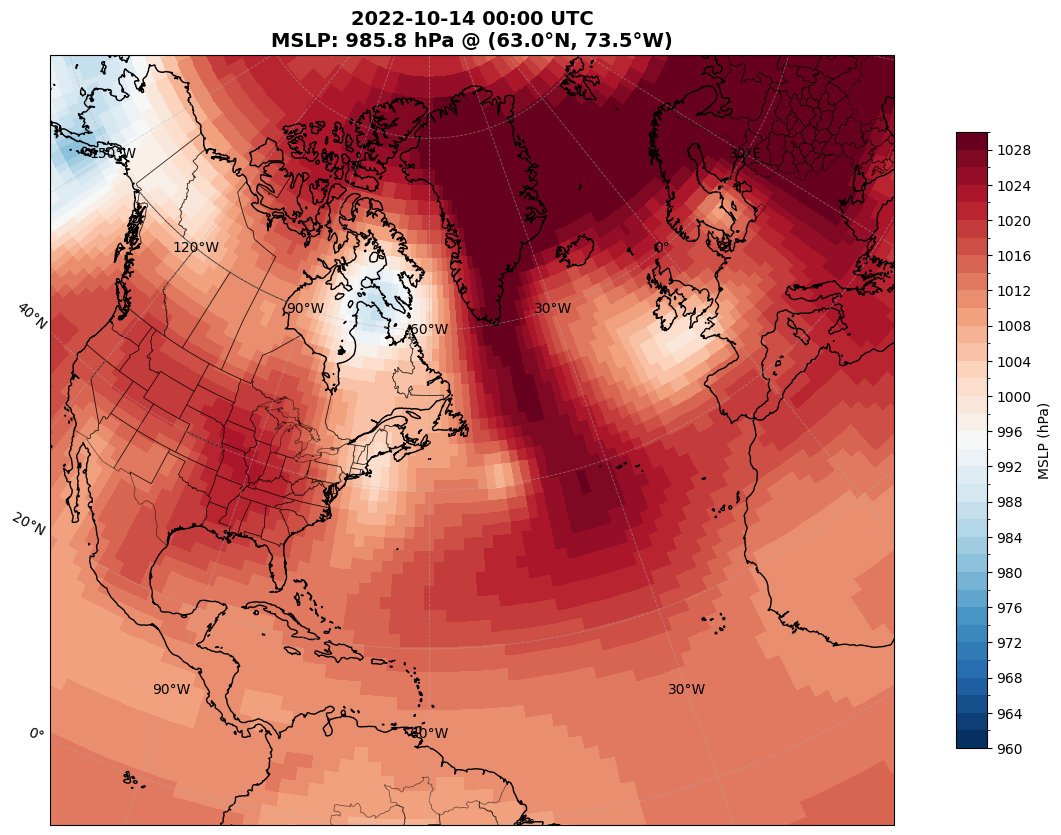

✓ Visualization disabled
Initial storms (t=0): 1
λ₀ crossings: 1
B-state events: 0
Interface 0 (1000 hPa): 1 crossings
Interface 1 (988 hPa): 0 crossings
Interface 2 (980 hPa): 0 crossings
Interface 3 (975 hPa): 0 crossings
Interface 4 (970 hPa): 0 crossings
Interface 5 (965 hPa): 0 crossings
λ₀ rate: 0.0667/day
B rate: 0.0000/day


In [23]:
# In your notebook
import numpy as np
import pandas as pd

# Create the tracker - NEW constructor signature
tracker = IFSEnsembleTracker(
    model=ffs.model,
    state_transformer=ffs.state_transformer,
    config=ffs.config,
    initial_dataset=ffs.initial_dataset,
    dataset_params=ffs.dataset_params,
    output_dir=ffs.output_dir,
    state_A=ffs.state_A_threshold,
    state_B=ffs.state_B_threshold,
    interfaces=ffs.interfaces[:-1],
    worker_id=ffs.worker_id,
    rank=ffs.rank,
    world_size=ffs.world_size,
    use_cps=ffs.use_cps,
    ifs_path='/glade/derecho/scratch/schreck/IFS.zarr'
)

init_time = '2022-09-29'
tracker.load_ifs_data(init_times=[init_time])
result = tracker.visualize_member(init_time=pd.Timestamp(init_time), member_idx=7)

if result:
    print(f"Initial storms (t=0): {result['n_initial_storms']}")
    print(f"λ₀ crossings: {len(result['crossings'])}")
    print(f"B-state events: {len(result['b_state_events'])}")
    for i, crossings in result['interface_crossings'].items():
        print(f"Interface {i} ({tracker.interfaces[i]} hPa): {len(crossings)} crossings")
    print(f"λ₀ rate: {result['lambda0_rate']:.4f}/day")
    print(f"B rate: {result['b_state_rate']:.4f}/day")

In [8]:
"""
Two-panel MSLP comparison: IFS ensemble member (left) vs ERA5 truth (right).

Usage:
    plotter = MSLPPanelPlotter(
        ifs_path="path/to/ifs.zarr",
        era5_path="path/to/era5_surface.zarr",
        latlons_path="path/to/latlons.nc",
        surface_geopotential_path="path/to/sfc_geo.nc",
    )

    fig = plotter.plot("2022-09-28 00:00", ifs_init_time="2022-09-21", member=0)
"""

import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
from scipy.ndimage import gaussian_filter
from credit.interp import mean_sea_level_pressure_simple as mslp_simple


class MSLPPanelPlotter:
    """Plots side-by-side IFS vs ERA5 MSLP panels for a given valid datetime."""

    def __init__(self, ifs_path, era5_path, latlons_path, surface_geopotential_path):
        """
        Args:
            ifs_path: Path to IFS ensemble zarr store.
            era5_path: Path to ERA5 surface zarr store (must contain SP, t2m).
            latlons_path: Path to lat/lon grid file for ERA5.
            surface_geopotential_path: Path to file with Z_GDS4_SFC and LSM.
        """
        self.ds_ifs = xr.open_zarr(ifs_path, consolidated=True)
        self.ds_era5 = xr.open_zarr(era5_path, consolidated=True)

        latlons = xr.open_dataset(latlons_path).load()
        self.era5_lats = latlons.latitude.values
        self.era5_lons_180 = np.where(latlons.longitude.values > 180,
                                      latlons.longitude.values - 360,
                                      latlons.longitude.values)

        with xr.open_dataset(surface_geopotential_path) as df:
            self.surface_geopotential = df["Z_GDS4_SFC"].values
            self.land_sea_mask = df["LSM"].values

    def plot(
        self,
        valid_time,
        ifs_init_time,
        member=0,
        extent=None,
        sigma=1.0,
        levels=None,
        figsize=(20, 8),
        save_path=None,
    ):
        valid_dt = pd.Timestamp(valid_time)
        init_dt = pd.Timestamp(ifs_init_time)

        if extent is None:
            extent = [-100, -10, 0, 85]
        if levels is None:
            levels = np.arange(960, 1032, 2)

        proj = ccrs.LambertConformal(
            central_longitude=(extent[0] + extent[1]) / 2,
            central_latitude=(extent[2] + extent[3]) / 2,
            standard_parallels=(30, 50),
        )

        ifs_mslp, ifs_lats, ifs_lons = self._get_ifs_mslp(init_dt, valid_dt, member)
        era5_mslp = self._get_era5_mslp(valid_dt)

        fig, (ax_ifs, ax_era5) = plt.subplots(
            1, 2, figsize=figsize, subplot_kw={"projection": proj}
        )

        norm = BoundaryNorm(levels, ncolors=plt.cm.RdBu_r.N, clip=True)
        label_dt = valid_dt.strftime("%Y-%m-%d %H:%M UTC")

        self._draw_panel(
            ax_ifs, ifs_mslp, ifs_lats, ifs_lons,
            norm, sigma, extent,
            title=f"IFS  member {member}  (init {init_dt.strftime('%Y-%m-%d %H:%MZ')})\n{label_dt}",
        )

        self._draw_panel(
            ax_era5, era5_mslp, self.era5_lats, self.era5_lons_180,
            norm, sigma, extent,
            title=f"ERA5 truth\n{label_dt}",
        )

        cbar = fig.colorbar(
            plt.cm.ScalarMappable(norm=norm, cmap="RdBu_r"),
            ax=[ax_ifs, ax_era5],
            orientation="horizontal",
            shrink=0.6,
            pad=0.04,
            label="MSLP (hPa)",
        )
        cbar.set_ticks(levels[::4])

        plt.tight_layout()

        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches="tight")
            print(f"Saved -> {save_path}")

        return fig

    # ------------------------------------------------------------------
    def _get_ifs_mslp(self, init_dt, valid_dt, member):
        traj = self.ds_ifs.sel(time=init_dt).isel(number=member)
        lead = valid_dt - init_dt

        deltas = traj.prediction_timedelta.values
        idx = int(np.argmin(np.abs(deltas - np.timedelta64(lead))))

        mslp_pa = traj.mean_sea_level_pressure.isel(prediction_timedelta=idx).values
        while mslp_pa.ndim > 2:
            mslp_pa = mslp_pa[0]

        lats = traj.latitude.values
        lons = traj.longitude.values
        lons_180 = np.where(lons > 180, lons - 360, lons)

        mslp_hpa = mslp_pa / 100.0
        if mslp_hpa.shape == (len(lons), len(lats)):
            mslp_hpa = mslp_hpa.T

        return mslp_hpa, lats, lons_180

    def _get_era5_mslp(self, valid_dt):
        ds_time = self.ds_era5.sel(time=valid_dt, method='nearest')

        surface_pressure_pa = ds_time['SP'].values
        temperature_k = ds_time['t2m'].values

        mslp_pa = mslp_simple(surface_pressure_pa, temperature_k, self.surface_geopotential)
        return mslp_pa / 100.0

    @staticmethod
    def _draw_panel(ax, mslp_hpa, lats, lons, norm, sigma, extent, title=""):
        ax.set_extent(extent, crs=ccrs.PlateCarree())

        mslp_smooth = gaussian_filter(mslp_hpa, sigma=sigma) if sigma > 0 else mslp_hpa
        LON, LAT = np.meshgrid(lons, lats, indexing="xy")

        ax.pcolormesh(
            LON, LAT, mslp_smooth,
            norm=norm, cmap="RdBu_r",
            transform=ccrs.PlateCarree(),
            shading="nearest", zorder=1,
        )

        ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=1.0)
        ax.add_feature(cfeature.STATES.with_scale("50m"), linewidth=0.5, alpha=0.6)

        gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.4, linestyle="--")
        gl.top_labels = False
        gl.right_labels = False

        min_idx = np.nanargmin(mslp_hpa)
        i, j = np.unravel_index(min_idx, mslp_hpa.shape)
        min_val = float(mslp_hpa[i, j])
        min_lat, min_lon = float(lats[i]), float(lons[j])

        ax.plot(
            min_lon, min_lat, marker="o", markersize=8,
            markeredgecolor="black", markeredgewidth=1.5, color="lime",
            transform=ccrs.PlateCarree(), zorder=10,
        )
        ax.text(
            min_lon + 1.5, min_lat - 1.5, f"{min_val:.0f} hPa",
            transform=ccrs.PlateCarree(), fontsize=9, fontweight="bold",
            color="black", bbox=dict(facecolor="white", alpha=0.7, pad=2),
            zorder=11,
        )

        ax.set_title(title, fontsize=12, fontweight="bold")

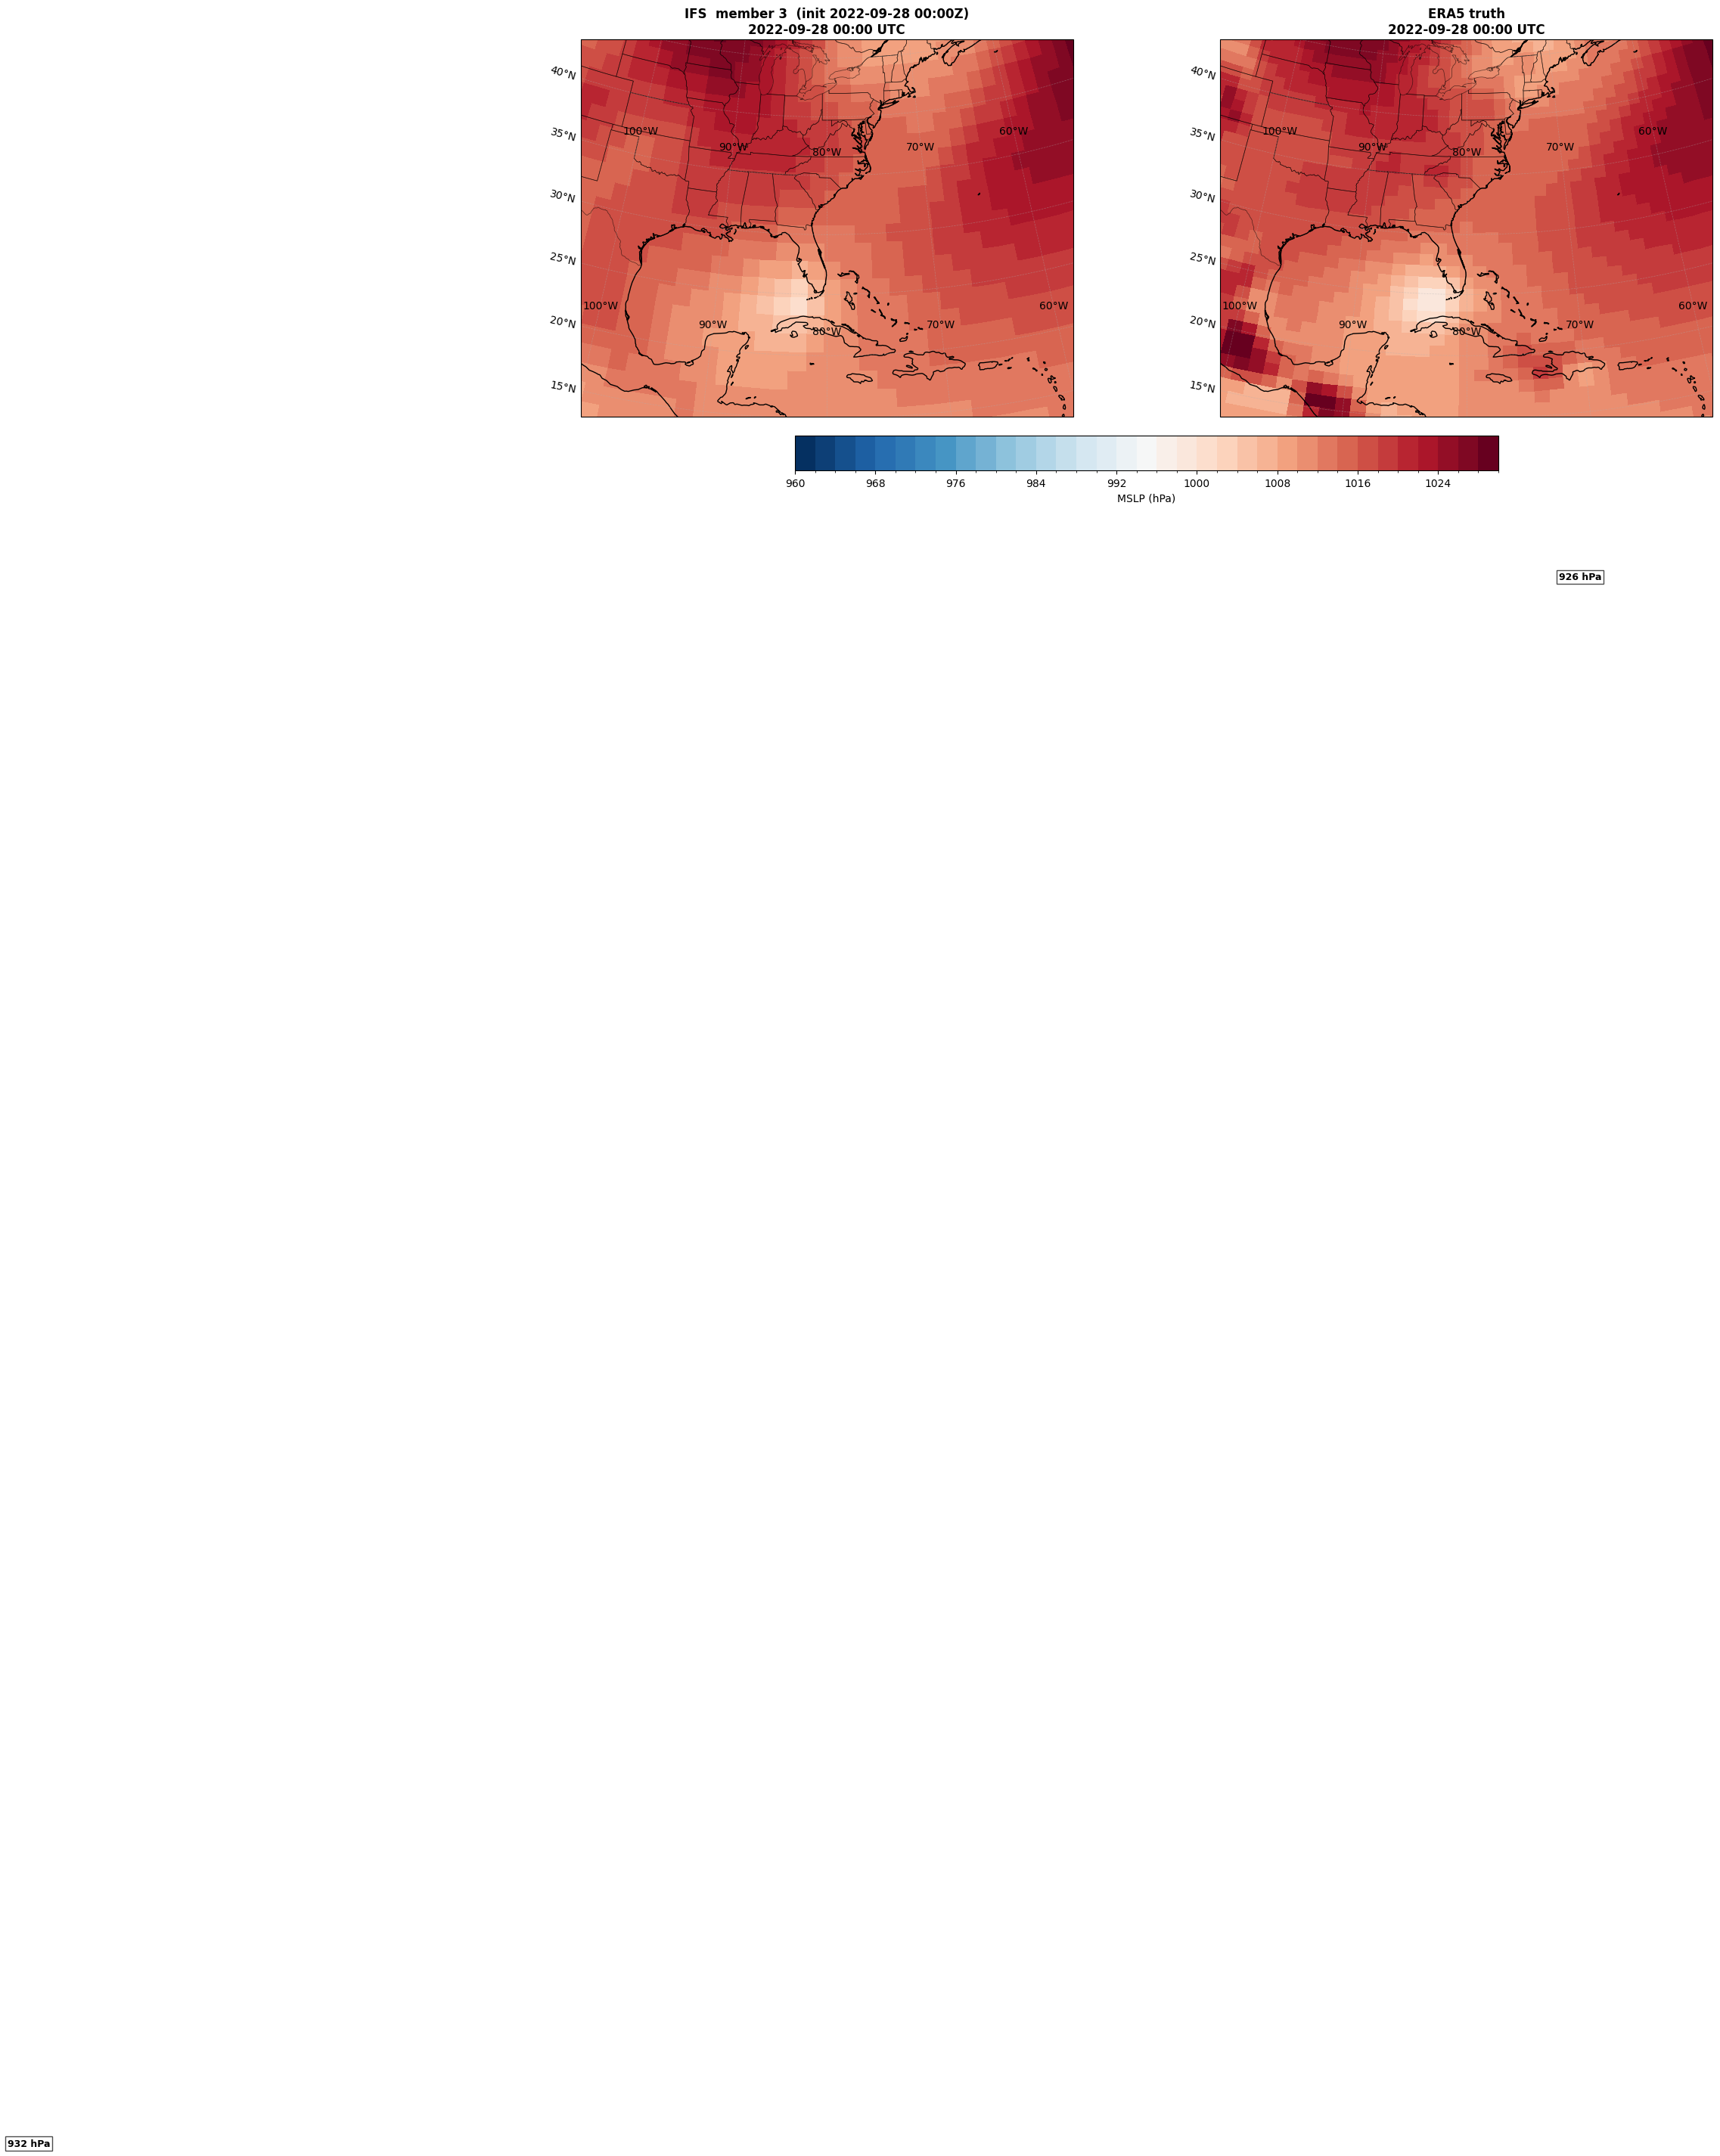

In [21]:
plotter = MSLPPanelPlotter(
    ifs_path='/glade/derecho/scratch/schreck/IFS.zarr',
    era5_path="/glade/campaign/cisl/aiml/ksha/CREDIT_data/ERA5_mlevel_cesm_stage1/all_in_one/ERA5_mlevel_cesm_6h_lev16_2022.zarr",
    latlons_path=conf["loss"]["latitude_weights"],
    surface_geopotential_path='/glade/campaign/cisl/aiml/credit/static_scalers/static_whole_20250416_1deg.nc'
)

# With options
fig = plotter.plot(
    "2022-09-28 00:00",
    ifs_init_time="2022-09-28",
    member=3,
    extent=[-100, -60, 15, 45],   # zoom into Gulf/Caribbean
    sigma=1.0,                     # more smoothing
)

In [24]:
"""
Debug the late-September IFS flux drop using process_member logic
but with verbose storm-by-storm output.
"""
import numpy as np
import xarray as xr
import pandas as pd
from scipy.ndimage import gaussian_filter

# ── config ────────────────────────────────────────────────────────────────────
IFS_PATH   = '/glade/derecho/scratch/schreck/IFS.zarr'
STATE_A    = 1008.0
STATE_B    = 965.0
LAMBDA0    = 1000.0
INTERFACES = [1000, 988, 980, 975, 970]
SEP_DEG    = 12.0
BASIN      = dict(lat_min=10., lat_max=45., lon_min=-98., lon_max=-20.)

DATES = [
    '2022-09-27T00:00:00',
    '2022-09-27T12:00:00',
    '2022-09-28T00:00:00',
    '2022-09-28T12:00:00',
    '2022-09-29T00:00:00',
]
MEMBERS_TO_CHECK = range(50) # [0, 1, 2, 3, 4]
# ──────────────────────────────────────────────────────────────────────────────

print(f"Loading {IFS_PATH}...")
ds = xr.open_zarr(IFS_PATH, consolidated=True)

lons_raw = ds.longitude.values
lats_raw = ds.latitude.values
lons_180 = np.where(lons_raw > 180, lons_raw - 360, lons_raw)

lat_mask  = (lats_raw >= BASIN['lat_min']) & (lats_raw <= BASIN['lat_max'])
lon_mask  = (lons_180 >= BASIN['lon_min']) & (lons_180 <= BASIN['lon_max'])
basin_mask = lat_mask[:, None] & lon_mask[None, :]
lat_grid, lon_grid = np.meshgrid(lats_raw, lons_180, indexing='ij')


def find_local_minima(mslp_hpa, exclude_centers=None):
    field = np.where(basin_mask, mslp_hpa, np.nan)
    if exclude_centers:
        for clat, clon in exclude_centers:
            dist = np.sqrt((lat_grid - clat)**2 + (lon_grid - clon)**2)
            field = np.where(dist < SEP_DEG, np.nan, field)
    smooth = gaussian_filter(field, sigma=1.5)
    minima = []
    for i in range(1, smooth.shape[0]-1):
        for j in range(1, smooth.shape[1]-1):
            v = smooth[i, j]
            if not np.isfinite(v):
                continue
            if np.all(v <= smooth[i-1:i+2, j-1:j+2]):
                minima.append((float(mslp_hpa[i,j]), float(lats_raw[i]), float(lons_180[j])))
    return minima


def merge_minima(minima):
    merged = []
    for mslp, lat, lon in minima:
        done = False
        for k, (m, la, lo) in enumerate(merged):
            if np.sqrt((lat-la)**2 + (lon-lo)**2) < SEP_DEG:
                if mslp < m:
                    merged[k] = (mslp, lat, lon)
                done = True
                break
        if not done:
            merged.append((mslp, lat, lon))
    return merged


def process_member_verbose(traj, member_idx, init_str):
    lats  = traj.latitude.values
    lons  = traj.longitude.values
    lons_ = np.where(lons > 180, lons - 360, lons)

    tracked  = {}
    next_id  = 0
    init_ids = set()
    crossings = []
    b_events  = []

    n_steps = len(traj.prediction_timedelta)

    for lead_idx in range(n_steps):
        mslp_pa = traj.mean_sea_level_pressure.isel(prediction_timedelta=lead_idx).values
        while mslp_pa.ndim > 2:
            mslp_pa = mslp_pa[0]
        mslp = mslp_pa / 100.0
        if mslp.shape == (len(lons), len(lats)):
            mslp = mslp.T

        lead_h = float(traj.prediction_timedelta.values[lead_idx] / np.timedelta64(1, 'h'))

        # update tracked storms
        tracked_minima = []
        for sid, s in tracked.items():
            slat, slon = s['location']
            dist = np.sqrt((lat_grid - slat)**2 + (lon_grid - slon)**2)
            sm   = gaussian_filter(mslp, sigma=1.5)
            local = np.where(dist < SEP_DEG, sm, np.nan)
            if np.all(np.isnan(local)):
                continue
            idx = np.nanargmin(local)
            i, j = np.unravel_index(idx, local.shape)
            tracked_minima.append((float(mslp[i,j]), float(lats[i]), float(lons_[j])))

        exclude = [s['location'] for s in tracked.values()]
        new_min = find_local_minima(mslp, exclude_centers=exclude)
        minima  = merge_minima(tracked_minima + new_min)

        # match storms to minima
        matched_m = set()
        for sid, s in list(tracked.items()):
            slat, slon = s['location']
            best, best_d = None, 99999
            for mi, (mv, mlat, mlon) in enumerate(minima):
                if mi in matched_m: continue
                d = np.sqrt((mlat-slat)**2 + (mlon-slon)**2)
                if d < SEP_DEG and d < best_d:
                    best, best_d = mi, d
            if best is not None:
                mv, mlat, mlon = minima[best]
                tracked[sid]['location']   = (mlat, mlon)
                tracked[sid]['mslp']       = mv
                tracked[sid]['lost_count'] = 0
                matched_m.add(best)
            else:
                tracked[sid]['lost_count'] += 1

        # add new unmatched minima as new storms
        for mi, (mv, mlat, mlon) in enumerate(minima):
            if mi not in matched_m:
                sid = next_id; next_id += 1
                tracked[sid] = dict(location=(mlat,mlon), mslp=mv,
                                    saved=False, lost_count=0)
                if lead_idx == 0:
                    init_ids.add(sid)
                    print(f"  [m{member_idx:02d} +{lead_h:4.0f}h] PRE-EXISTING #{sid}: "
                          f"{mv:.1f} hPa @ ({mlat:.1f}N, {mlon:.1f}E)")

        # remove lost storms
        for sid in list(tracked.keys()):
            if tracked[sid]['lost_count'] >= 2:
                del tracked[sid]

        # check state transitions
        for sid in list(tracked.keys()):
            s = tracked[sid]
            slat, slon = s['location']

            # dissipation
            if s['mslp'] > STATE_A:
                del tracked[sid]
                continue

            # B-state — delete storm regardless, only count if new genesis
            if s['mslp'] < STATE_B:
                tag = '[GENESIS→B]' if sid not in init_ids else '[PRE-EXISTING, skipped]'
                print(f"  [m{member_idx:02d} +{lead_h:4.0f}h] STATE_B  #{sid}: "
                      f"{s['mslp']:.1f} hPa @ ({slat:.1f}N, {slon:.1f}E) {tag}")
                if sid not in init_ids:
                    b_events.append(dict(storm_id=sid, lead_h=lead_h,
                                         mslp=s['mslp'], lat=slat, lon=slon))
                del tracked[sid]
                continue

            # lambda0 crossing (new storms only, once only)
            if sid not in init_ids and not s.get('saved', False):
                if s['mslp'] < LAMBDA0:
                    print(f"  [m{member_idx:02d} +{lead_h:4.0f}h] LAMBDA0  #{sid}: "
                          f"{s['mslp']:.1f} hPa @ ({slat:.1f}N, {slon:.1f}E)")
                    crossings.append(dict(storm_id=sid, lead_h=lead_h,
                                          mslp=s['mslp'], lat=slat, lon=slon))
                    s['saved'] = True

    return crossings, b_events


print()
for date_str in DATES:
    t = pd.Timestamp(date_str)

    total_cross = 0
    total_b     = 0

    print(f"{'='*70}")
    print(f"INIT: {date_str}  (members {MEMBERS_TO_CHECK})")
    print(f"{'='*70}")

    for m in MEMBERS_TO_CHECK:
        traj = ds.sel(time=t).isel(number=m)
        cross, b = process_member_verbose(traj, m, date_str)
        total_cross += len(cross)
        total_b     += len(b)

    n_checked = len(MEMBERS_TO_CHECK)
    rate = total_cross / (n_checked * 15.0)
    print(f"  SUMMARY ({n_checked} members): "
          f"lambda0_crossings={total_cross}, b_events={total_b}, "
          f"flux_rate={rate:.4f}/day")
    print()

Loading /glade/derecho/scratch/schreck/IFS.zarr...

INIT: 2022-09-27T00:00:00  (members range(0, 50))
  [m00 +   0h] PRE-EXISTING #0: 994.8 hPa @ (21.0N, -84.0E)
  [m01 +   6h] LAMBDA0  #0: 992.8 hPa @ (21.0N, -84.0E)
  [m01 + 234h] LAMBDA0  #7: 998.9 hPa @ (42.0N, -66.0E)
  [m02 +   0h] PRE-EXISTING #0: 995.8 hPa @ (21.0N, -84.0E)
  [m03 +   0h] PRE-EXISTING #0: 993.9 hPa @ (21.0N, -84.0E)
  [m04 +   0h] PRE-EXISTING #0: 994.5 hPa @ (21.0N, -84.0E)
  [m05 +   0h] PRE-EXISTING #0: 996.0 hPa @ (21.0N, -84.0E)
  [m06 +   0h] PRE-EXISTING #0: 995.3 hPa @ (21.0N, -84.0E)
  [m07 +   0h] PRE-EXISTING #0: 995.9 hPa @ (21.0N, -84.0E)
  [m07 + 186h] LAMBDA0  #12: 999.1 hPa @ (37.5N, -54.0E)
  [m08 +   6h] LAMBDA0  #0: 996.5 hPa @ (21.0N, -84.0E)
  [m09 +   0h] PRE-EXISTING #0: 995.0 hPa @ (21.0N, -84.0E)
  [m09 + 252h] LAMBDA0  #15: 998.4 hPa @ (45.0N, -63.0E)
  [m10 +   0h] PRE-EXISTING #0: 995.2 hPa @ (21.0N, -84.0E)
  [m11 +   0h] PRE-EXISTING #0: 994.9 hPa @ (21.0N, -84.0E)
  [m11 + 186h] L